## 1) Importing libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from functions import plots

In [2]:
random_state = 1
primary_color = "#1c3148"
secondary_color = "#c56715"

## 2) Reading datasets

### 2.1) Categories

#### 2.1.1) Reading

In [3]:
categories_df = pd.read_csv(
    filepath_or_buffer = "./archive/Data_Entry_2017.csv"
)

categories_df = categories_df[~categories_df["Finding Labels"].str.contains(r"\|")]

print(categories_df.shape)
categories_df.head(2)

(91324, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN


#### 2.1.2) Labels distribution

<p>As we can see, we have a imbalanced dataset. We should take care of this before pass the data into the future model, otherwise it could understand that <code>No Finding</code> is the more important feature - which it is not the intention of this project.</p>

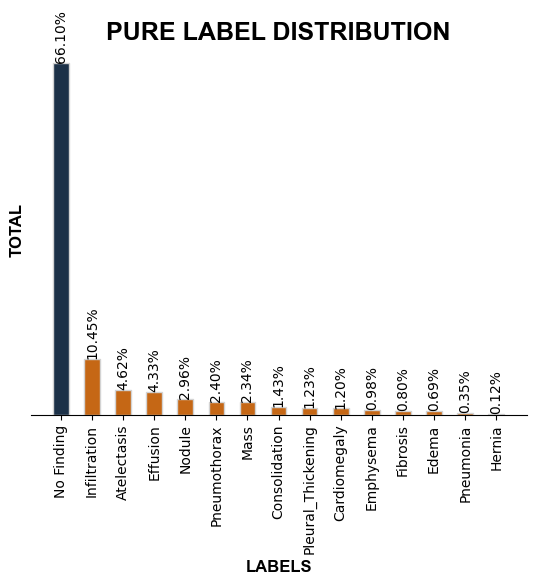

In [4]:
plot_df = categories_df["Finding Labels"].value_counts(sort = True, normalize = True)

fig, ax = plt.subplots()

plots.plot_bar(
    ax = ax,
    x_values = plot_df.index,
    y_values = plot_df.values,
    colors =  [primary_color] + (plot_df.shape[0] -1)*[secondary_color],
    title = {
        "text": "PURE LABEL DISTRIBUTION",
        "size": 18
    },
    x_label = {
        "text": "LABELS"
    },
    y_label = {
        "text": "TOTAL"
    },
    legends = plot_df.index,
    formater = "{:,.2%}",
    tooltip_align = "edge",
    tooltip_rotation = 90
)

ax.tick_params(axis = "x", labelrotation = 90)

plt.show()

#### 2.1.3) Describe

<p>One of the most important things to learn about this dataset is that image <b>Width</b> and <b>Height</b> are in the range <code>(900, 3800)</code>, approximately.</p>

In [5]:
categories_df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
count,91324.000000,91324.000000,91324.000000,91324.000000,91324.000000,91324.000000,91324.000000,0.0
mean,7.463942,14181.944341,46.522053,2638.675332,2490.888069,0.155802,0.155802,NaN
std,14.202716,8449.722024,16.768857,343.051565,403.309396,0.016230,0.016230,NaN
min,0.000000,1.000000,1.000000,1143.000000,966.000000,0.115000,0.115000,NaN
25%,0.000000,7034.000000,34.000000,2500.000000,2048.000000,0.143000,0.143000,NaN
50%,2.000000,13729.500000,48.000000,2504.000000,2541.000000,0.143000,0.143000,NaN
75%,8.000000,20624.000000,59.000000,2992.000000,2991.000000,0.168000,0.168000,NaN
max,182.000000,30805.000000,414.000000,3827.000000,4715.000000,0.198800,0.198800,NaN


### 2.2) Images

#### 2.2.1) Reading

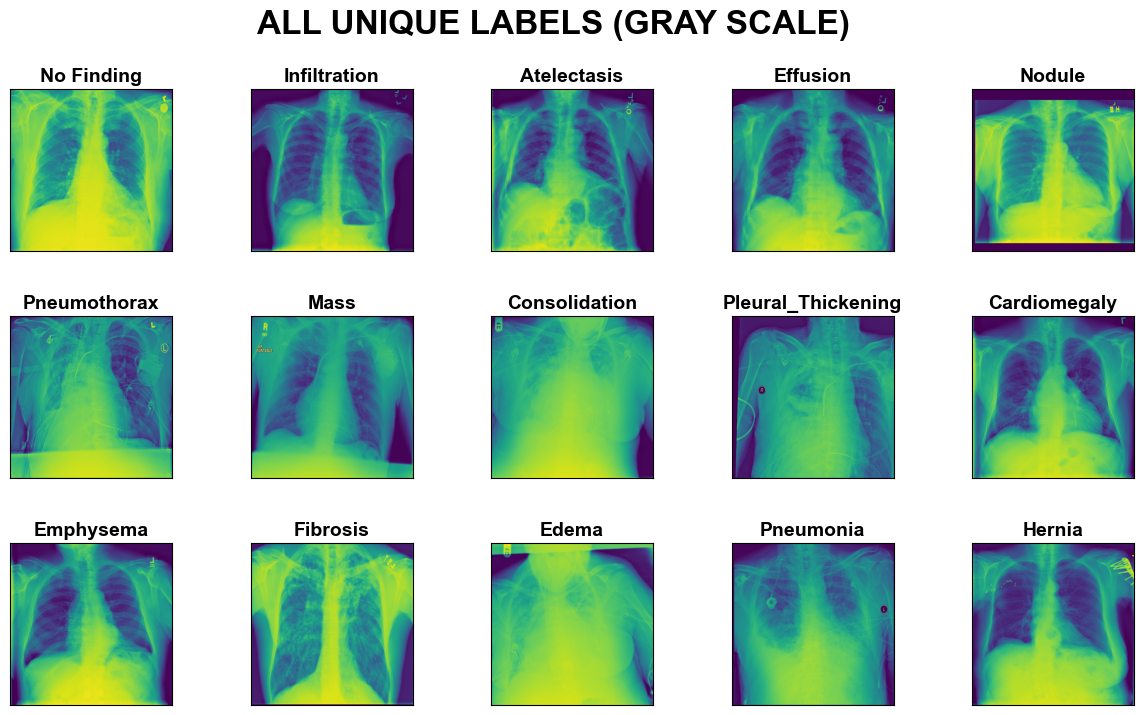

In [6]:
#Getting first imagem example for plot
image_samples = {}

for label in plot_df.index:

    image_samples[label] = categories_df[
        categories_df["Finding Labels"] == label
    ].reset_index().loc[0, "Image Index"]

fig, axs = plt.subplots(
    ncols = 5,
    nrows = 3,
    figsize = (15, 8),
    gridspec_kw = {
        "hspace": 0.4
    }
)

axs = axs.flatten()

for index, (key, value) in enumerate(image_samples.items()):
    image = tf.keras.utils.load_img(
        path = f"./archive/images_001/images/{value}",
        color_mode = "grayscale",
        # target_size is lower than range (900, 3800):
        target_size = (500, 500),
    )

    image = tf.keras.utils.img_to_array(
        image
    )/255.

    axs[index].imshow(image)
    axs[index].set_title(
        label = key,
        fontsize = 14,
        fontfamily = "arial",
        fontweight = "bold"
    )
    axs[index].set_xticks(ticks = [])
    axs[index].set_yticks(ticks = [])

plt.suptitle(
    t = "ALL UNIQUE LABELS (GRAY SCALE)",
    fontsize = 24,
    fontweight = "bold",
    fontfamily = "arial"
)
plt.show()

#### 2.2.2) Handling imbalancing

<p align="justify">As we saw previously, <code>No Finding</code> and <code>Infiltration</code> are the majority class amoung them all, surpassing more than three quarters of the whole dataset. Not only that, but having others minor diagnosis such as <code>Fibrosis</code>, <code>Edema</code>, <code>Pneumonia</code> and <code>Hernia</code>, could also be a problem because the model do not have enough data to learn.</p>

<p align="justify">Because of that - in order to have a more precisely model, we are going to randomly drop some cases of <code>No Finding</code> and <code>Infiltration</code> and also all <code>Fibrosis</code>, <code>Edema</code>, <code>Pneumonia</code> and <code>Hernia</code> diagnosis.</p>

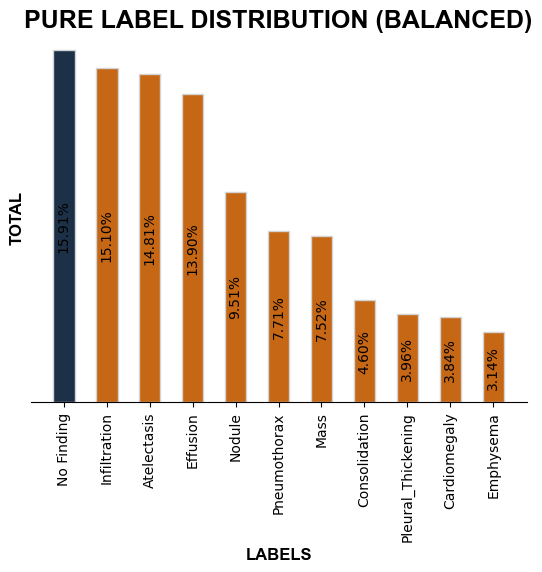

In [7]:
#Removing all minority diagnosis:
categories_df = categories_df[
    ~categories_df["Finding Labels"].isin(
        values = ["Fibrosis", "Edema", "Pneumonia", "Hernia"]
    )
]

#Splitting categories_df dataset into no_finding_df, infiltration_df and minority_df:
no_finding_df = categories_df[categories_df["Finding Labels"] == "No Finding"].copy().sample(
    frac = 0.075,
    random_state = random_state
)
infiltration_df = categories_df[categories_df["Finding Labels"] == "Infiltration"].copy().sample(
    frac = 0.45,
    random_state = random_state
)
other_df = categories_df[~categories_df["Finding Labels"].isin(values = ["No Finding", "Infiltration"])].copy()


categories_df = pd.concat(
    [
        no_finding_df, infiltration_df, other_df
    ],
    ignore_index = True
    
)

plot_df = categories_df["Finding Labels"].value_counts(sort = True, normalize = True)
plot_df_v2 = categories_df["Finding Labels"].value_counts(sort = True, normalize = False)

fig, ax = plt.subplots()

plots.plot_bar(
    ax = ax,
    x_values = plot_df.index,
    y_values = plot_df.values,
    colors =  [primary_color] + (plot_df.shape[0] -1)*[secondary_color],
    title = {
        "text": "PURE LABEL DISTRIBUTION (BALANCED)",
        "size": 18
    },
    x_label = {
        "text": "LABELS"
    },
    y_label = {
        "text": "TOTAL"
    },
    legends = plot_df.index,
    formater = "{:,.2%}",
    tooltip_align = "center",
    tooltip_rotation = 90
)

ax.tick_params(axis = "x", labelrotation = 90)

plt.show()

#### 2.2.3) Mapping unique labels 

<p>Our series of images do not have their labels already specify in their names, which forces us to map all sorts of unique labels in order to train the model.</p>

In [8]:
labels_dict = dict(zip(plot_df.index, [i for i in range(len(plot_df))]))

print(labels_dict)

{'No Finding': 0, 'Infiltration': 1, 'Atelectasis': 2, 'Effusion': 3, 'Nodule': 4, 'Pneumothorax': 5, 'Mass': 6, 'Consolidation': 7, 'Pleural_Thickening': 8, 'Cardiomegaly': 9, 'Emphysema': 10}


#### 2.2.4) Creating dataset

In [ ]:
categories_df["label_num"] = categories_df["Finding Labels"].map(labels_dict)
mapeamento_img_label = dict(zip(categories_df["Image Index"], categories_df["label_num"]))

paths = []
labels = []

for folder in Path("./archive").iterdir():
    if folder.name.startswith("images") and folder.is_dir():
        images_folder = folder / "images"
        if images_folder.exists():
            for archive in images_folder.iterdir():
                label = mapeamento_img_label.get(archive.name)
                if label is not None:
                    paths.append(str(archive))
                    labels.append(label)

def loading_preprocessing_image(caminho_arquivo, label):
    img_raw = tf.io.read_file(caminho_arquivo)
    img = tf.image.decode_png(img_raw, channels=1)
    img = tf.image.resize(img, [400, 400])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

dataset_pre_numpy = tf.data.Dataset.from_tensor_slices((paths, labels))
dataset_pre_numpy = dataset_pre_numpy.map(loading_preprocessing_image, num_parallel_calls=tf.data.AUTOTUNE)

numpy_dataset = dataset_pre_numpy.batch(len(paths))

X, y = next(numpy_dataset.as_numpy_iterator())

print(f"X Shape (Images): {X.shape}")
print(f"y Shape (Targets): {y.shape}")

X Shape (Images): (28452, 400, 400, 1)
y Shape (Targets): (28452,)


### 3) Saving dataset

In [12]:
np.save(
    file = "./dataset/X.npy", arr = X
)

np.save(
    file = "./dataset/y.npy", arr = y
)